<a href="https://colab.research.google.com/github/TRACE-Structures/bimquake/blob/main/demo/notebooks/bimquake_pilot_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Earthquake Resilience with pilot building**

This Jupyter Notebook demonstrates the functions of the **Assessment of Earthquake Resilience** module with the example of the two-storey Palazzo Poniatowski Guadagni building.

The module implements linear and non-linear computations and visualizations for analyzing the earthquake resilience of a given building.

### Imports

In [ ]:
! pip install bimquake

In [2]:
import bimquake
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

### Data inputs

The following user inputs are needed for the calculations:
- latitude and longitude of the building (in decimal degrees)
- soil category - ranges from hard rock (`A`) to very soft or problematic soils (`E`)
- nominal life - the intended design service life of the structure (in years)
- topographic category - the influence of terrain features (such as hills and ridges) on wind or seismic effects. Ranges from `T1` (no inpact, flat terrain) to `T4` (upper half of a ridge, maximum amplification)
- importance class - the criticality of a structure, influences the level of seismic safety required
    - Class `I`: Low importance (e. g., agricultural or temporary building)
    - Class `II`: Ordinary structure (standard residential, commercial or office building)
    - Class `III`: Building with high occupancy or social importance (e.g., school, assembly hall)
    - Class `IV`: Essential facility and structure of vital importance for civil protection, which must remain operational after an earthquake (e.g., hospital, emergency center)
- `.xls` or `.xlsx` file with wall properties of the building in a predefined [format](https://buildchain.ilab.sztaki.hu/templates)

In [3]:
data_path = 'https://raw.githubusercontent.com/TRACE-Structures/bimquake/main/demo/data/pilot_building.xlsx'
excel_file = pd.ExcelFile(data_path)
S = bimquake.create_equivalent_frame_model_from_excel(excel_file)

### Coordinate check

In [4]:
latitude = 43.7874
longitude = 11.2499

In [5]:
ParaTR, city, country = bimquake.get_Parameters(latitude, longitude)
print("{}, {}".format(city, country))

Loading formatted geocoded file...
Florence, IT


In [6]:
f = bimquake.get_map(latitude, longitude, city, country)
f

In [7]:
ParaTR

,Return Period,ag,Fo,Tc*
0,30.0,0.047018,2.551014,0.252808
1,50.0,0.056464,2.586081,0.267521
2,72.0,0.064100,2.593636,0.276378
3,101.0,0.072345,2.590411,0.281871
4,140.0,0.080685,2.597692,0.287275
5,201.0,0.093504,2.531818,0.293817
6,475.0,0.131090,2.420610,0.301819
7,975.0,0.167652,2.390029,0.310319
8,2475.0,0.221719,2.411010,0.318801


### Settings

In [8]:
soil_category = 'A'
nominal_life = 50
topographic_category = 'T1'
importance_class = 'I'

In [9]:
S.set_location(latitude, longitude)
S.set_seismic_loading(ParaTR)
S.set_seismic_design_parameters(soil_category, nominal_life, topographic_category, importance_class)

servicee life: 50
importance class: I
class: I


### 2D layout

In [10]:
floor_id = 0
S.plot_floor_layout(floor_id)

### Linear analysis calculation

In [11]:
q = 1.5
q_ort = 3

Sfs = S.run_linear_static_analysis(q, q_ort)

In [12]:
chosen_floor = 0
Sfs[chosen_floor]

,Wall_ID,SF_VX,SF_MX,SF_MOX,SF_VY,SF_MY,SF_MOY
0,1,1.483941,0.996650,2.674065,NaN,NaN,NaN
1,2,1.716389,4.519532,3.037706,NaN,NaN,NaN
2,3,1.391959,0.752381,2.513313,NaN,NaN,NaN
3,4,1.542752,1.658812,1.616191,NaN,NaN,NaN
4,5,1.394779,1.771713,1.469098,NaN,NaN,NaN
...,...,...,...,...,...,...,...
156,157,NaN,NaN,NaN,1.591000,3.562599,0.771084
157,158,NaN,NaN,NaN,1.591000,2.284155,0.771084
158,159,NaN,NaN,NaN,1.704418,1.229501,1.132456
159,160,NaN,NaN,NaN,1.670423,1.195389,1.113338


In [13]:
direction = 'Y' # or 'X'
floor_id = 0
safety_factor_type = 'Shear' # or 'Bending in plane' or 'Bending out of plane'

S.plot_wall_safety_factors(Sfs, direction, floor_id, safety_factor_type)

### Pushover analysis calculation

In [14]:
method = 'Ductility' # or 'Drift'
algorithm = 'incr' # or 'add' (Incremental or Additive)
mu = 1.5

In [15]:
k_ult_TOT, Hult_TOT, vr_ult_TOT, L_organized = S.get_force_displacement_capacity_curve(method, algorithm, mu)
v_bl, H_bl = S.get_bilinear_capacity_curve_coords(vr_ult_TOT, Hult_TOT)
pushover_results = S.assess_seismic_performance_get_ADRS_params(k_ult_TOT, Hult_TOT, vr_ult_TOT, H_bl, v_bl)

### Outputs

In [16]:
df2 = S.get_global_vulnerability_metrics(v_bl, pushover_results)
df2

,Direction,Safety Index,PGA_C,TR,δ,d* (t)
0,X,1.24,0.14,598.0,11.97,11.23
1,Y,1.03,0.12,361.0,11.3,13.44


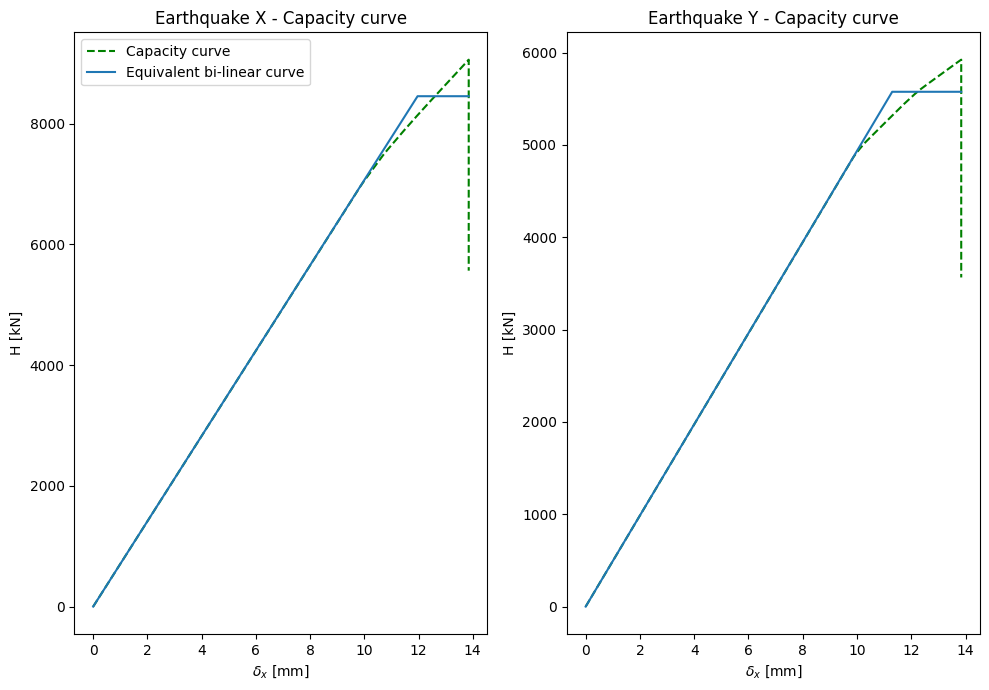

In [17]:
fig1 = S.plot_capacity_curve(vr_ult_TOT, Hult_TOT, v_bl, H_bl)

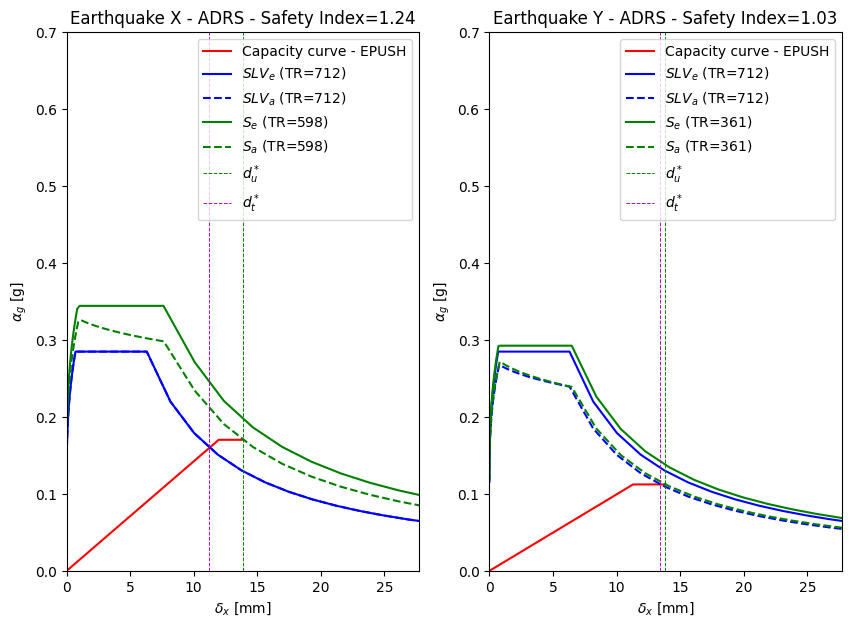

In [18]:
fig2 = S.plot_ADRS_demand_and_capacity(v_bl, pushover_results)

In [19]:
direction = 'X' # or 'Y'
floor_id = 0

S.plot_failing_walls(L_organized, 'X', floor_id)